# MINUT — transform and case studies

MINUT bins each LC-HRMS run on a fixed (m/z, retention time) grid and keeps, in each bin,
the most intense point together with its m/z and RT. The classifiers of the paper work on
the flattened `[intensity | m/z | RT]` vector of each run.

This notebook shows the transform on a toy example, applies it to a file if you have one,
then reruns the three case studies of the paper from the deposited feature tables
(`data/`, Git LFS). Expected values are listed with each step.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from minut import GRIDS, minut, feature_vector, transform_file
import case_studies_rerun as cs

## The transform

Two scans, a 2 x 2 grid. Each bin keeps its most intense point; when two points have the
same intensity the first one seen is kept; empty bins have intensity 0 and no coordinates.

In [2]:
grid = (100.0, 120.0, 10.0, 2.0, 4.0, 1.0)   # m/z 100-120 by 10, RT 2-4 min by 1
scans = [(2.2, [101.0, 102.0, 112.0], [4.0, 9.0, 3.0]),
         (3.2, [113.0], [6.0])]
intensity, mz, rt = minut(scans, grid)
print(intensity, mz, rt, sep="\n\n")
print("\nfeature vector:", np.round(feature_vector(intensity, mz, rt, grid), 3))

[[9. 3.]
 [0. 6.]]

[[102. 112.]
 [ nan 113.]]

[[2.2 2.2]
 [nan 3.2]]

feature vector: [1.    0.333 0.    0.667 0.1   0.6   0.    0.65  0.1   0.1   0.    0.6  ]


## A real file

Point `RUN` to an mzML or mzXML file. `ms_levels=(1,)` bins the MS1 scans only; the
deposited tables of the two public cohorts were computed from every scan of the file
(`ms_levels=None`, see the README). The same operation is available from the command line
with `extract_minut.py`.

In [3]:
RUN = None   # e.g. "path/to/run.mzXML"
if RUN:
    vector = transform_file(RUN, GRIDS["covid"], ms_levels=None)
    print(vector.shape, "non-empty bins:", int((vector[:21600] > 0).sum()))

## Case studies

Expected values (paper): milk — CV accuracy 0.92, bootstrap accuracy 0.95 (SD 0.04),
ROC AUC 0.97, permutation p 0.0099; lung — 151/151 correct on the validation cohort,
AUC 1.00, training CV 1.00; COVID-19 — 5-fold CV accuracy 0.854 ± 0.100, AUC 0.866 ± 0.129.
The COVID selector fits a 1000-tree forest in each fold, so this cell takes a few minutes.

In [4]:
results = {name: run() for name, run in (("milk", cs.milk), ("lung", cs.lung), ("covid", cs.covid))}
pd.DataFrame(results).T

,cv_accuracy,cv_sd,permutation_p,test_accuracy,test_auc,bootstrap_accuracy,bootstrap_sd,n_features,cv_auc,auc_sd,fold_auc
milk,0.921905,0.03858,0.009901,0.944444,0.973251,0.945361,0.037842,101.0,NaN,NaN,NaN
lung,1.0,0.0,NaN,1.0,1.0,1.0,0.0,7.0,NaN,NaN,NaN
covid,0.853846,0.099835,NaN,NaN,NaN,NaN,NaN,NaN,0.86627,0.128926,0.8929;0.9762;0.9762;0.6250;0.8611


## Bin size (lung, Figure S4)

Training-set cross-validation for three m/z bin widths with the 50 most important features,
the exploratory sweep behind the choice of 2 m/z.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

for width in (10, 2, 0.5):
    X, y, train, _ = cs.load_lung(mz_width=width)
    pipeline = Pipeline([("select", cs.GiniSelector(50, 2024)),
                         ("forest", RandomForestClassifier(n_estimators=100, random_state=1791))])
    scores = cross_val_score(pipeline, X[train], y[train], cv=5)
    print(f"{width:>4g} m/z: {X.shape[1] // 2:>5d} bins  CV accuracy {scores.mean():.3f} ± {scores.std():.3f}")

  10 m/z:   475 bins  CV accuracy 1.000 ± 0.000


   2 m/z:  2375 bins  CV accuracy 1.000 ± 0.000


 0.5 m/z:  9500 bins  CV accuracy 0.988 ± 0.024


## Candidate regions (COVID-19, Figures 3 and 4)

The m/z coordinate stored in each bin tells which ion won the bin in each sample. For the
bin discussed in the paper (m/z 322.0-322.5, RT 15-16 min) a DBSCAN cluster around the
sphingosine d18:1 [M+Na]+ mass gathers 51 of the 63 samples; the other 12 hold a different ion.

,bin,hypothesis,n,n_control,n_severe,mean_mz,sd_ppm,mass_error_ppm,U_control_first,p,median_control,median_severe
0,16044,sphingosine d18:1 [M+Na]+,51,26,25,322.270875,1.545190,-2.405328,458.0,1.253920e-02,0.001192,0.000704
1,2436,"valine [M+H]+, RT 4-5 min",63,31,32,118.086066,0.970099,-1.641540,888.0,7.349619e-08,0.002109,0.001468
2,1236,"valine [M+H]+, RT 3-4 min",63,31,32,118.086064,0.912180,-1.658759,893.0,5.004563e-08,0.002162,0.001506


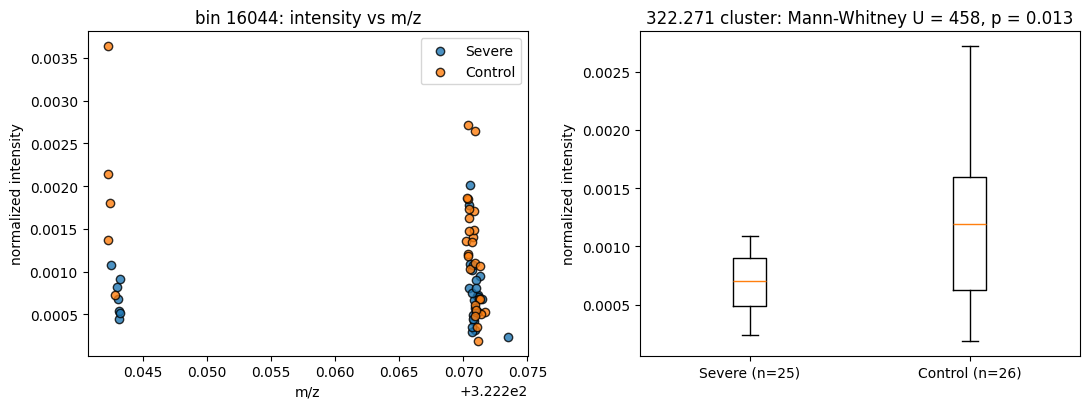

In [6]:
regions = cs.covid_regions()
display(regions)

X, y, subjects = cs.load_covid()
coords = cs.bin_coordinates(X, 16044, GRIDS["covid"])
keep = cs.mass_cluster(coords["mz"].to_numpy(), 322.27165, coords["intensity"].to_numpy() > 0)
groups = np.where(y == 1, "Severe", "Control")

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.2))
for group, color in (("Severe", "tab:blue"), ("Control", "tab:orange")):
    sel = groups == group
    left.scatter(coords["mz"][sel], coords["intensity"][sel], c=color, edgecolor="k", alpha=.8, label=group)
left.set(xlabel="m/z", ylabel="normalized intensity", title="bin 16044: intensity vs m/z")
left.legend()
right.boxplot([coords["intensity"][keep & (y == 1)], coords["intensity"][keep & (y == 0)]],
              tick_labels=[f"Severe (n={(keep & (y == 1)).sum()})", f"Control (n={(keep & (y == 0)).sum()})"],
              showfliers=False)
u, p = regions.loc[regions["bin"] == 16044, ["U_control_first", "p"]].iloc[0]
right.set(ylabel="normalized intensity", title=f"322.271 cluster: Mann-Whitney U = {u:g}, p = {p:.3f}")
plt.tight_layout()

## PABA-compatible region (milk, Figure 2)

Bin 183 (m/z 130-140, RT 6-8 min). The group at m/z 138.05 is almost exclusively
conventional milk (105 conventional vs 8 organic samples over the 177).

,scope,n,conventional,organic,fisher_p,mean_mz,sd_mz,mean_rt,sd_rt
0,all 177,113,105,8,2.364733e-15,138.054743,0.000112,6.489419,0.145663
1,training,87,82,5,1.270254e-13,138.054751,0.000113,6.476569,0.038917
2,test,26,23,3,6.226467e-03,138.054718,0.000105,6.532418,0.291111


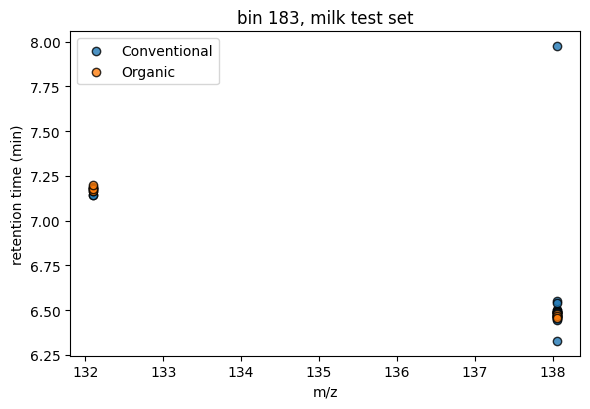

In [7]:
display(cs.milk_paba())

X, y, train, test = cs.load_milk()
coords = cs.bin_coordinates(X, 183, GRIDS["milk"], components=("mz", "rt"))
fig, ax = plt.subplots(figsize=(6, 4.2))
for label, color, name in ((0, "tab:blue", "Conventional"), (1, "tab:orange", "Organic")):
    sel = test[y[test] == label]
    ax.scatter(coords["mz"][sel], coords["rt"][sel], c=color, edgecolor="k", alpha=.8, label=name)
ax.set(xlabel="m/z", ylabel="retention time (min)", title="bin 183, milk test set")
ax.legend()
plt.tight_layout()